In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/My Drive/advertising_sales_data-original.csv')

In [ ]:
display(df.isnull().sum())

,0
TV,0
Radio,2
Newspaper,0
Sales,0


In [ ]:
df=df.dropna()

print("Cleaned! Shape is now:", df.shape)

Cleaned! Shape is now: (198, 4)


In [ ]:
display(df.isnull().sum())

,0
TV,0
Radio,0
Newspaper,0
Sales,0


Question 1


In [ ]:
avg_tv=df['TV'].mean()
print(f"Average TV Spending: {avg_tv:.2f}")

Average TV Spending: 146.79


Question 2


In [ ]:
import pandas as pd


# Look at the data
print(df.head())
print(df[['Radio', 'Sales']].describe())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
            Radio       Sales
count  198.000000  198.000000
mean    23.260606   15.125758
std     14.921914    5.309478
min      0.000000    1.600000
25%      9.925000   11.000000
50%     22.400000   16.000000
75%     36.575000   19.150000
max     49.600000   27.000000


In [ ]:
# Method 1: Simple way
radio_sales_corr = df['Radio'].corr(df['Sales'])
print(f"Radio-Sales Correlation: {radio_sales_corr:.4f}")

# Method 2: Get all correlations at once
print("\nAll correlations with Sales:")
print(df.corr()['Sales'].sort_values(ascending=False))

Radio-Sales Correlation: 0.3497

All correlations with Sales:
Sales        1.000000
TV           0.901372
Radio        0.349728
Newspaper    0.159125
Name: Sales, dtype: float64


In [ ]:
# Strong positive correlation?
if radio_sales_corr > 0.7:
    print("Strong relationship: Radio ads DO influence sales!")
elif radio_sales_corr > 0.4:
    print("Moderate relationship: Radio helps somewhat")
elif radio_sales_corr > 0:
    print("Weak positive relationship: Radio has slight effect")
else:
    print("Negative or no relationship: Radio doesn't help much")

Weak positive relationship: Radio has slight effect


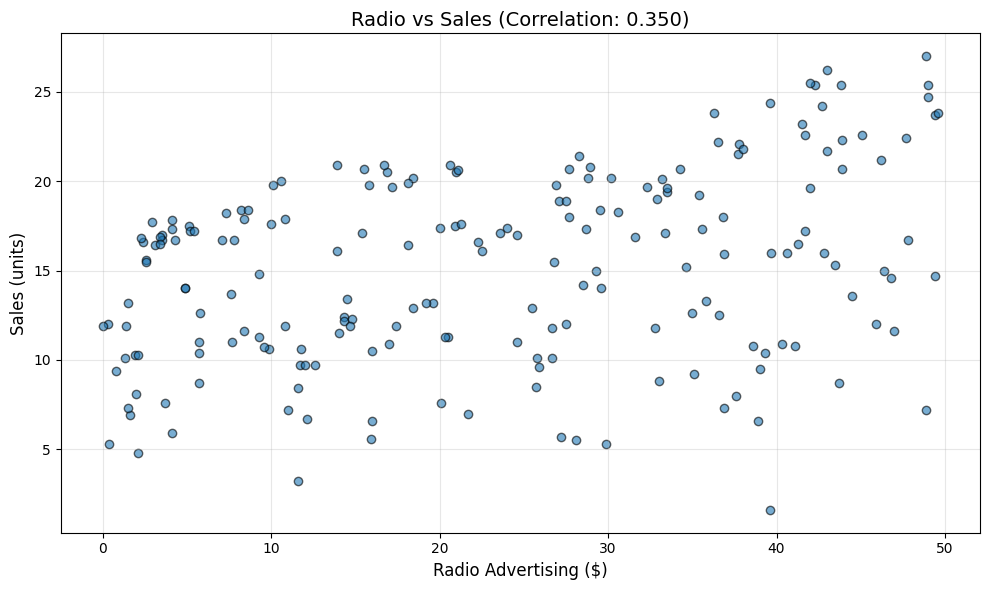

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Radio'], df['Sales'], alpha=0.6, edgecolor='k')
plt.xlabel('Radio Advertising ($)', fontsize=12)
plt.ylabel('Sales (units)', fontsize=12)
plt.title(f'Radio vs Sales (Correlation: {radio_sales_corr:.3f})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Question 3


In [ ]:
tv_corr=df['TV'].corr(df['Sales'])
radio_corr=df['Radio'].corr(df['Sales'])
newspaper_corr=df['Newspaper'].corr(df['Sales'])

print("Correlation with Sales:")
print(f"TV:        {tv_corr:.4f}")
print(f"Radio:     {radio_corr:.4f}")
print(f"Newspaper: {newspaper_corr:.4f}")

Correlation with Sales:
TV:        0.9014
Radio:     0.3497
Newspaper: 0.1591


In [ ]:
# Create a dictionary
correlations = {
    'TV': tv_corr,
    'Radio': radio_corr,
    'Newspaper': newspaper_corr
}

# Find highest impact
highest_impact = max(correlations, key=correlations.get)
highest_value = correlations[highest_impact]

print(f"\nHighest Impact: {highest_impact}")
print(f"Correlation: {highest_value:.4f}")


Highest Impact: TV
Correlation: 0.9014


In [ ]:
# Sort from highest to lowest
sorted_corr = sorted(correlations.items(), key=lambda x: x[1], reverse=True)

print("\nRanking by Impact on Sales:")
for rank, (medium, corr) in enumerate(sorted_corr, 1):
    print(f"{rank}. {medium:12} : {corr:.4f}")


Ranking by Impact on Sales:
1. TV           : 0.9014
2. Radio        : 0.3497
3. Newspaper    : 0.1591


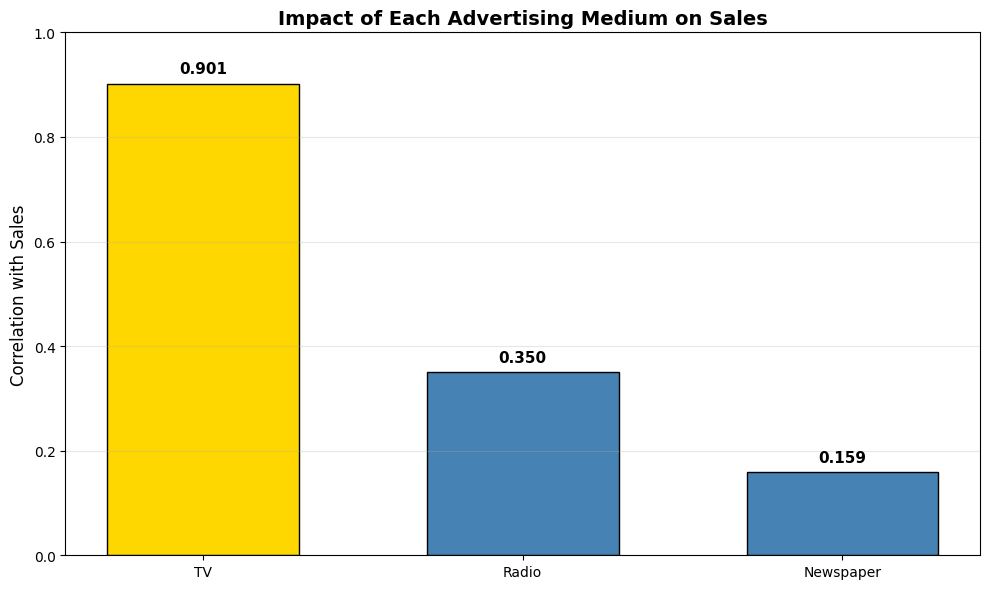

In [ ]:
import matplotlib.pyplot as plt

# Bar chart
mediums = list(correlations.keys())
values = list(correlations.values())

plt.figure(figsize=(10, 6))
colors = ['gold' if v == max(values) else 'steelblue' for v in values]
plt.bar(mediums, values, color=colors, edgecolor='black', width=0.6)
plt.ylabel('Correlation with Sales', fontsize=12)
plt.title('Impact of Each Advertising Medium on Sales', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Question 4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# Separate features (X) and target (y)
df= df.dropna()
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print(f"Data shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")
print(f"Target: Sales")

Data shape: (198, 3)
Features: ['TV', 'Radio', 'Newspaper']
Target: Sales


In [ ]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 158 rows
Test set: 40 rows


In [ ]:
# Create and train
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Print the formula
print("\n" + "="*50)
print("LINEAR REGRESSION FORMULA")
print("="*50)
print(f"Sales = {model.intercept_:.4f} + ", end="")
print(f"({model.coef_[0]:.4f} × TV) + ", end="")
print(f"({model.coef_[1]:.4f} × Radio) + ", end="")
print(f"({model.coef_[2]:.4f} × Newspaper)")

print("\nInterpretation:")
print(f"- Base sales (no ads): {model.intercept_:.2f} units")
print(f"- Each $1 on TV adds: {model.coef_[0]:.4f} units")
print(f"- Each $1 on Radio adds: {model.coef_[1]:.4f} units")
print(f"- Each $1 on Newspaper adds: {model.coef_[2]:.4f} units")


LINEAR REGRESSION FORMULA
Sales = 4.6057 + (0.0543 × TV) + (0.1041 × Radio) + (0.0038 × Newspaper)

Interpretation:
- Base sales (no ads): 4.61 units
- Each $1 on TV adds: 0.0543 units
- Each $1 on Radio adds: 0.1041 units
- Each $1 on Newspaper adds: 0.0038 units


In [ ]:
# Predict on training data
y_train_pred = model.predict(X_train)

# Predict on test data
y_test_pred = model.predict(X_test)

print("Predictions made!")

Predictions made!


In [ ]:
# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Training R² Score: {train_r2:.4f}")
print(f"Test R² Score:     {test_r2:.4f}")
print(f"Test RMSE:         {test_rmse:.4f} units")
print(f"Test MAE:          {test_mae:.4f} units")

print("\nInterpretation:")
print(f"The model explains {test_r2*100:.1f}% of sales variance")
print(f"Average prediction error: {test_mae:.2f} units")


MODEL PERFORMANCE
Training R² Score: 0.9032
Test R² Score:     0.8991
Test RMSE:         1.4208 units
Test MAE:          1.0652 units

Interpretation:
The model explains 89.9% of sales variance
Average prediction error: 1.07 units


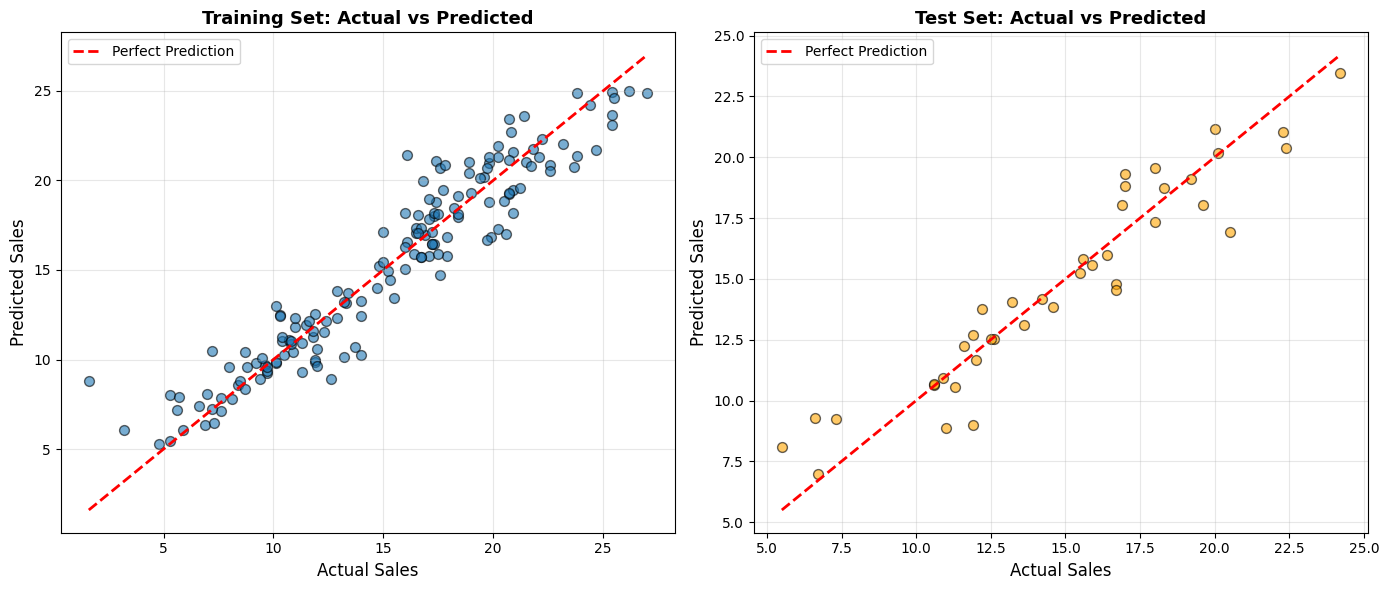

In [ ]:
plt.figure(figsize=(14, 6))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.6, edgecolor='k', s=50)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.title('Training Set: Actual vs Predicted', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Test set
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='orange', edgecolor='k', s=50)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.title('Test Set: Actual vs Predicted', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

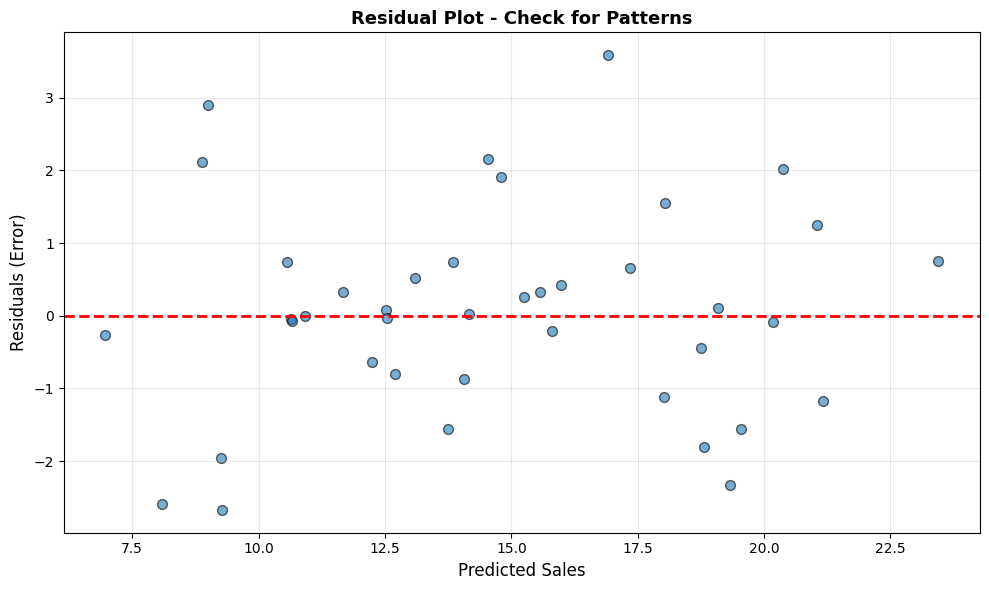

Residual Analysis:
Mean residual: 0.0567 (should be close to 0)
Std of residuals: 1.4377


In [ ]:
# Calculate residuals
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6, edgecolor='k', s=50)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Residuals (Error)', fontsize=12)
plt.title('Residual Plot - Check for Patterns', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Residual Analysis:")
print(f"Mean residual: {residuals.mean():.4f} (should be close to 0)")
print(f"Std of residuals: {residuals.std():.4f}")

Question 5


In [ ]:
# New advertising expenditure
# TV: $200, Radio: $40, Newspaper: $50

new_data = [[200, 40, 50]]

print("New data to predict:")
print(f"TV: ${200}")
print(f"Radio: ${40}")
print(f"Newspaper: ${50}")

New data to predict:
TV: $200
Radio: $40
Newspaper: $50


In [ ]:
# Predict
predicted_sales = model.predict(new_data)

print(f"\nPredicted Sales: {predicted_sales[0]:.2f} units")


Predicted Sales: 19.82 units


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Manual calculation to verify
manual_prediction = (model.intercept_ +
                     model.coef_[0] * 200 +
                     model.coef_[1] * 40 +
                     model.coef_[2] * 50)

print(f"Manual calculation: {manual_prediction:.2f} units")
print(f"Model prediction:   {predicted_sales[0]:.2f} units")
print(f"Match: {np.isclose(manual_prediction, predicted_sales[0])}")

Manual calculation: 19.82 units
Model prediction:   19.82 units
Match: True


In [ ]:
print(f"\nWith $200 on TV, $40 on Radio, $50 on Newspaper:")
print(f"Expected sales: {predicted_sales[0]:.2f} units")
print(f"\nThis prediction comes with ±{test_mae:.2f} units of error")


With $200 on TV, $40 on Radio, $50 on Newspaper:
Expected sales: 19.82 units

This prediction comes with ±1.07 units of error


Question 6


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Create scaler
scaler = StandardScaler()

# Fit and transform
X_normalized = scaler.fit_transform(X)

print("Original data (first 3 rows):")
print(X.head(3).values)

print("\nNormalized data (first 3 rows):")
print(X_normalized[:3])

# Check: should be centered around 0
print("\nMean of normalized data:", X_normalized.mean(axis=0))
print("Std of normalized data:", X_normalized.std(axis=0))

Original data (first 3 rows):
[[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]]

Normalized data (first 3 rows):
[[ 0.9688214   0.97683509  1.76736874]
 [-1.18943467  1.0776132   0.66120143]
 [-1.50689368  1.52103689  1.77195865]]

Mean of normalized data: [-3.81288716e-16 -6.28004943e-17  2.15315981e-16]
Std of normalized data: [1. 1. 1.]


In [ ]:
# Split
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print(f"Normalized training set: {X_train_norm.shape[0]} rows")
print(f"Normalized test set: {X_test_norm.shape[0]} rows")

Normalized training set: 158 rows
Normalized test set: 40 rows


In [ ]:
# Create and train normalized model
model_norm = LinearRegression()
model_norm.fit(X_train_norm, y_train_norm)

print("Normalized model trained!")

Normalized model trained!


In [ ]:
# Predictions
y_train_pred_norm = model_norm.predict(X_train_norm)
y_test_pred_norm = model_norm.predict(X_test_norm)

# Metrics
train_r2_norm = r2_score(y_train_norm, y_train_pred_norm)
test_r2_norm = r2_score(y_test_norm, y_test_pred_norm)
test_rmse_norm = np.sqrt(mean_squared_error(y_test_norm, y_test_pred_norm))

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

print("\nOriginal Model (Not Normalized):")
print(f"  Training R²: {train_r2:.4f}")
print(f"  Test R²:     {test_r2:.4f}")
print(f"  Test RMSE:   {test_rmse:.4f}")

print("\nNormalized Model:")
print(f"  Training R²: {train_r2_norm:.4f}")
print(f"  Test R²:     {test_r2_norm:.4f}")
print(f"  Test RMSE:   {test_rmse_norm:.4f}")

print("\nDifference in R²:")
diff = test_r2_norm - test_r2
print(f"  {diff:+.4f}")

if abs(diff) < 0.01:
    print("\nConclusion: Normalization has MINIMAL impact on Linear Regression")
    print("(This is expected - Linear Regression is scale-invariant)")
else:
    print(f"\nConclusion: Normalization {'improved' if diff > 0 else 'worsened'} performance")


MODEL COMPARISON

Original Model (Not Normalized):
  Training R²: 0.9032
  Test R²:     0.8991
  Test RMSE:   1.4208

Normalized Model:
  Training R²: 0.9032
  Test R²:     0.8991
  Test RMSE:   1.4208

Difference in R²:
  +0.0000

Conclusion: Normalization has MINIMAL impact on Linear Regression
(This is expected - Linear Regression is scale-invariant)


Question 7

In [ ]:
# Select only Radio and Newspaper
X_subset = df[['Radio', 'Newspaper']]
y = df['Sales']

print("Original features: TV, Radio, Newspaper")
print("New features: Radio, Newspaper")
print(f"Columns removed: TV")

Original features: TV, Radio, Newspaper
New features: Radio, Newspaper
Columns removed: TV


In [ ]:
# Split
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    X_subset, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_sub.shape[0]} rows, {X_train_sub.shape[1]} features")
print(f"Test set: {X_test_sub.shape[0]} rows, {X_test_sub.shape[1]} features")

Training set: 158 rows, 2 features
Test set: 40 rows, 2 features


In [ ]:
# Create and train
model_subset = LinearRegression()
model_subset.fit(X_train_sub, y_train_sub)

print("Subset model trained!")

Subset model trained!


In [ ]:
print("\n" + "="*50)
print("SUBSET MODEL FORMULA")
print("="*50)
print(f"Sales = {model_subset.intercept_:.4f} + ", end="")
print(f"({model_subset.coef_[0]:.4f} × Radio) + ", end="")
print(f"({model_subset.coef_[1]:.4f} × Newspaper)")

print("\nNote: TV coefficient is gone!")
print("Model is simpler with only 2 features instead of 3")


SUBSET MODEL FORMULA
Sales = 11.7923 + (0.1308 × Radio) + (0.0148 × Newspaper)

Note: TV coefficient is gone!
Model is simpler with only 2 features instead of 3


In [ ]:
# Predictions
y_train_pred_sub = model_subset.predict(X_train_sub)
y_test_pred_sub = model_subset.predict(X_test_sub)

print("Predictions made for subset model!")

Predictions made for subset model!


In [ ]:
# Calculate metrics
train_r2_sub = r2_score(y_train_sub, y_train_pred_sub)
test_r2_sub = r2_score(y_test_sub, y_test_pred_sub)
test_rmse_sub = np.sqrt(mean_squared_error(y_test_sub, y_test_pred_sub))
test_mae_sub = mean_absolute_error(y_test_sub, y_test_pred_sub)

print("\n" + "="*60)
print("SUBSET MODEL (Radio + Newspaper Only)")
print("="*60)
print(f"Training R²: {train_r2_sub:.4f}")
print(f"Test R²:     {test_r2_sub:.4f}")
print(f"Test RMSE:   {test_rmse_sub:.4f}")
print(f"Test MAE:    {test_mae_sub:.4f}")


SUBSET MODEL (Radio + Newspaper Only)
Training R²: 0.1488
Test R²:     -0.0519
Test RMSE:   4.5875
Test MAE:    3.8295


In [ ]:
print("\n" + "="*70)
print("THREE-MODEL COMPARISON")
print("="*70)

print("\n1. FULL MODEL (TV + Radio + Newspaper):")
print(f"   Test R²:   {test_r2:.4f}")
print(f"   Test RMSE: {test_rmse:.4f}")
print(f"   Test MAE:  {test_mae:.4f}")

print("\n2. SUBSET MODEL (Radio + Newspaper only):")
print(f"   Test R²:   {test_r2_sub:.4f}")
print(f"   Test RMSE: {test_rmse_sub:.4f}")
print(f"   Test MAE:  {test_mae_sub:.4f}")

print("\n3. IMPACT OF REMOVING TV:")
r2_drop = test_r2 - test_r2_sub
rmse_increase = test_rmse_sub - test_rmse
mae_increase = test_mae_sub - test_mae

print(f"   R² dropped by:   {r2_drop:.4f} ({r2_drop/test_r2*100:.1f}%)")
print(f"   RMSE increased: {rmse_increase:.4f} units ({rmse_increase/test_rmse*100:.1f}%)")
print(f"   MAE increased:  {mae_increase:.4f} units ({mae_increase/test_mae*100:.1f}%)")

print("\n" + "="*70)
print("CONCLUSION:")
print("="*70)
print(f"Removing TV causes {r2_drop/test_r2*100:.1f}% decrease in R²")
print(f"This confirms TV is CRITICAL for predictions")
print(f"Budget allocation: TV is most important!")


THREE-MODEL COMPARISON

1. FULL MODEL (TV + Radio + Newspaper):
   Test R²:   0.8991
   Test RMSE: 1.4208
   Test MAE:  1.0652

2. SUBSET MODEL (Radio + Newspaper only):
   Test R²:   -0.0519
   Test RMSE: 4.5875
   Test MAE:  3.8295

3. IMPACT OF REMOVING TV:
   R² dropped by:   0.9510 (105.8%)
   RMSE increased: 3.1667 units (222.9%)
   MAE increased:  2.7643 units (259.5%)

CONCLUSION:
Removing TV causes 105.8% decrease in R²
This confirms TV is CRITICAL for predictions
Budget allocation: TV is most important!


/tmp/ipykernel_574/956439784.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


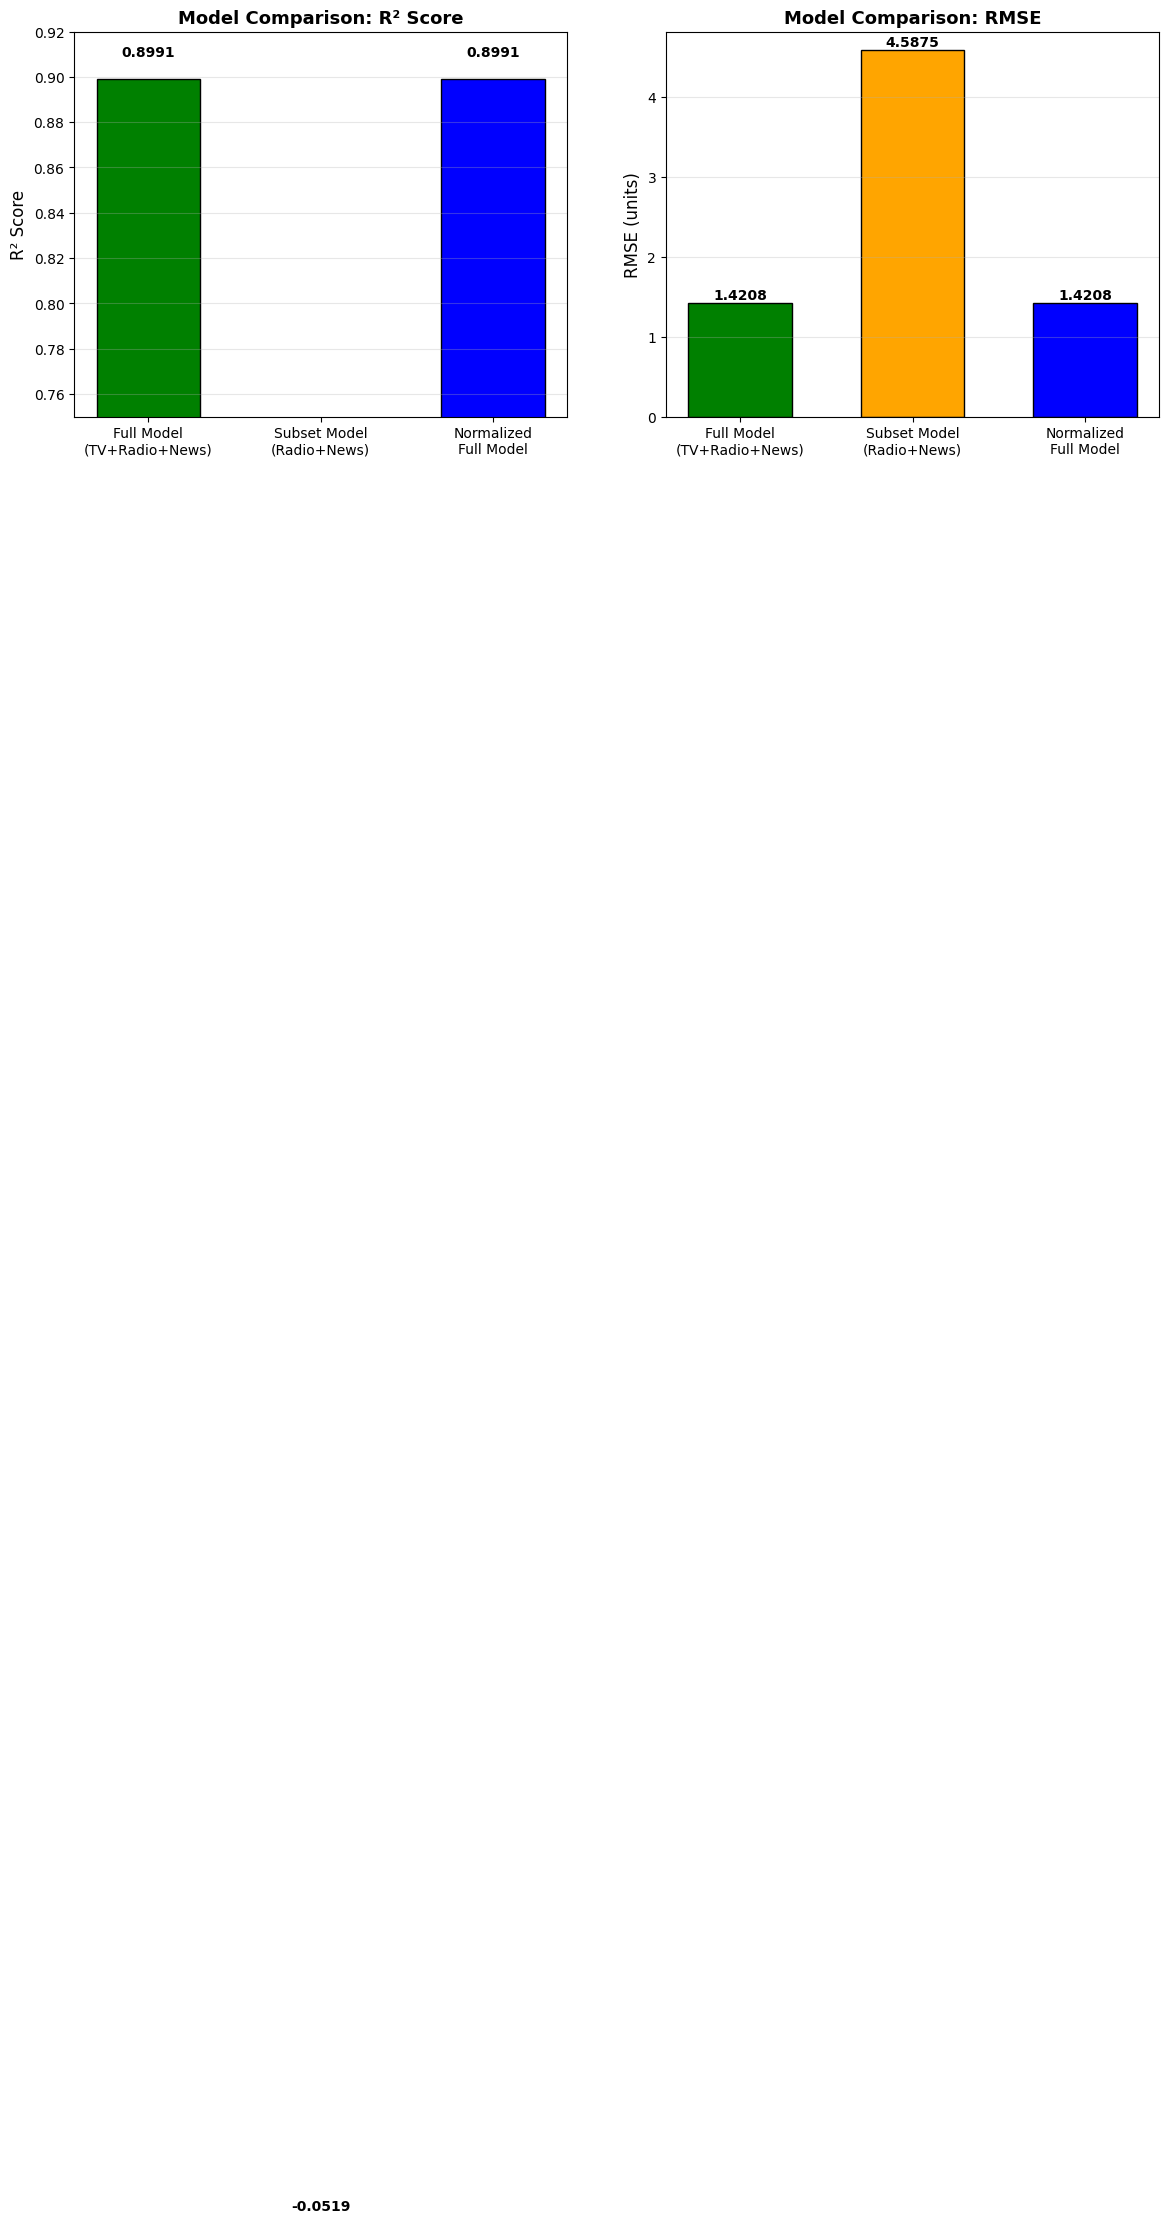

In [ ]:
import matplotlib.pyplot as plt

# Data for comparison
models = ['Full Model\n(TV+Radio+News)', 'Subset Model\n(Radio+News)', 'Normalized\nFull Model']
r2_scores = [test_r2, test_r2_sub, test_r2_norm]
rmse_scores = [test_rmse, test_rmse_sub, test_rmse_norm]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
axes[0].bar(models, r2_scores, color=['green', 'orange', 'blue'], edgecolor='black', width=0.6)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Comparison: R² Score', fontsize=13, fontweight='bold')
axes[0].set_ylim(0.75, 0.92)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE comparison
axes[1].bar(models, rmse_scores, color=['green', 'orange', 'blue'], edgecolor='black', width=0.6)
axes[1].set_ylabel('RMSE (units)', fontsize=12)
axes[1].set_title('Model Comparison: RMSE', fontsize=13, fontweight='bold')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()